In [ ]:
python ./svraster/train.py \
    --eval \
    --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
    --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04 \
    --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
    --res_downscale 8 \
    --test_every 20 \
    --ss 1.0 \
    --n_iter 95000 \
    --init_n_level 5 \
    --adapt_every 4000 \
    --adapt_from 4000 \
    --prune_until 90000 \
    --subdivide_until 90000 \
    --subdivide_max_num 2000000 \
    --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
                            10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
                            20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
                            30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
                            40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
                            50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
                            60999 61999 62999 63999 64999 65999 66999 67999 68999 69999 \
                            70999 71999 72999 73999 74999 75999 76999 77999 78999 79999 \
                            80999 81999 82999 83999 84999 85999 86999 87999 88999 89999 \
                            90999 91999 92999 93999 94999 \
    --sh_degree_init 0 \
    --black_background \
    --sh_degree 0


#                             # 90999 91999 92999 93999 94999 95999 96999 97999 98999 99999 \
#                             # 100999 101999 102999 103999 104999 105999 106999 107999 108999 109999 \
#                             # 110999 111999 112999 113999 114999 115999 116999 117999 118999 119999 \
#                             # 120999 121999 122999 123999 124999 125999 126999 127999 128999 129999 \

# 00

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [ ]:
def get_polynomials_coefs_sqrtinv(max_degree):
    list_b = [1]
    temp = 1
    for n in range(1, max_degree+1):
        temp *= (2 * n - 1) / (2 * n)
        list_b.append(temp)

    return np.array(list_b, np.float32)


def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=0,
        ss=1.0,
        white_background=False,
        black_background=True,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    geometry_info["morton_code_tensor"] = voxel_model_frame.vox_morton_code.clone().detach()
    geometry_info["vox_roots_tensor"] = voxel_model_frame.vox_root.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame.vox_conners_geo_params.clone().detach()

    if load_attribute_field:
        geometry_info["vox_params_color_tensor"] = voxel_model_frame.vox_static_rgbs.clone().detach()

    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.5, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):

        w, h = view_info.render_width, view_info.render_height

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute, # use as input voxel_attribute 
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0))

        return rendered_image

    def apply_A_transpose(
            self,
            lowres_denfield,
            decoded_attribute_field,
            scene_dataset,
            optim_opt={}
        ):

        MSE_calculator = torch.nn.MSELoss()

        approx_attribute_field = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.5, 
            dtype=torch.float32, device="cuda"
        ))
        optimizer = torch.optim.Adam([approx_attribute_field], lr=optim_opt.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()

        i=0
        for loop in range(optim_opt.get("num_scene_loop", 30)):
            k=0
            for view in train_views:
                ##
                optimizer.zero_grad()
                true_low_res_img   = lowres_denfield.apply_phi_with_F(decoded_attribute_field, view)
                approx_low_res_img = self.apply_phi_with_F(approx_attribute_field, view)
                ###
                mse_val = MSE_calculator(approx_low_res_img, true_low_res_img)
                mse_val.backward()
                ###
                if (i%100==0):
                    print(f"Apply_A_transpose: loop = {loop, k} iter = {i} psnr={-10 * np.log10(mse_val.detach().cpu())}")
                optimizer.step()
                i+=1
                k+=1

        output = approx_attribute_field.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output


    @torch.compiler.disable
    def apply_subview_phiTphi_with_F(self, voxel_attribute, view_info):

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_transformed_attribute = decompress_render.renderer.geometry_attention_transform_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_attribute=voxel_attribute, # use as input voxel_attribute 
        )

        return out_transformed_attribute
    
    
    # @torch.compiler.disable
    def apply_full_phiTphi_with_F(self, voxel_attribute, scene_dataset):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        list_views = scene_dataset.get_encoder_views()
        transformed_attribute = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )
        # vi = 0
        for view in list_views:
            # s = time.time()
            transformed_attribute = transformed_attribute + self.apply_subview_phiTphi_with_F(voxel_attribute, view)
            # print(f"++++ Apply_full_phiTphi_with_F: finished view {vi} in {time.time()-s}")
            # vi += 1

        return transformed_attribute


    # @torch.compiler.disable
    def apply_scaled_rotation_phiTphi(self, voxel_attribute, scene_dataset, rotation_opt={}):
        output = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )

        diagonal = self.apply_full_phiTphi_with_F(
            torch.ones_like(voxel_attribute), 
            scene_dataset
        ).detach()

        sqrtinv_diagonal = torch.where(
            diagonal>0.0,
            1.0 / torch.sqrt(diagonal),
            1.0
        )
        # sqrtinv_diagonal = torch.ones_like(diagonal)

        max_degree = rotation_opt.get("max_degree", 10)
        poly_coefs_sqrtinv = get_polynomials_coefs_sqrtinv(max_degree)
        signal = voxel_attribute

        muy_phi = rotation_opt.get("muy_phi", 1.0)
        output = signal * poly_coefs_sqrtinv[0] * np.sqrt(2*muy_phi)
        temp_val = signal
        
        for p in range(1, max_degree):
            s = time.time()
            Xb = self.apply_full_phiTphi_with_F(
                temp_val*sqrtinv_diagonal,
                scene_dataset
            ) * sqrtinv_diagonal

            temp_val = temp_val - 2 * muy_phi * Xb
            output = output + temp_val * poly_coefs_sqrtinv[p] * np.sqrt(2*muy_phi)
            # print(f"+++ Apply_scaled_rotation_phiTphi: finished degree {p} in {time.time() - s}")

        output = output * sqrtinv_diagonal
        return output


    def decoding_attribute_field(self, encoded_coefs, scene_dataset, rotation_opt={}):
        decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
            encoded_coefs,
            scene_dataset,
            rotation_opt
        )
        return decoded_attribute_field


    def encoding_attribute_field(self, voxel_delta_attribute, scene_dataset, rotation_opt={}, encoding_opts={}):

        MSE_calculator = torch.nn.MSELoss()
        MSE_calculator2 = torch.nn.MSELoss()

        encoded_coefs = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        ))
        lambda_l1 = encoding_opts.get("lambda_l1", 0.0)
        optimizer = torch.optim.Adam([encoded_coefs], lr=encoding_opts.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()

        i=0
        for loop in range(encoding_opts.get("num_loop", 30)):
            k=0
            for view in train_views:
                # Refresh
                # if (i%encoding_opts.get("update_frequency", 10)) == 0:
                    # if i > 0:
                        # print(f"Encoding_attribute_field: updating at loop = {loop} iter = {i}")
                        # mse_val.backward()
                        # optimizer.step()
                    
                    ## Refresh
                    # print(f"Encoding_attribute_field: Refreshing at loop = {loop} iter = {i}")

                optimizer.zero_grad()
                mse_val = lambda_l1 * encoded_coefs.abs().sum()
                decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
                    encoded_coefs,
                    scene_dataset,
                    rotation_opt
                )

                true_rendered_img_field   = self.apply_phi_with_F(voxel_delta_attribute, view).detach()
                approx_rendered_img_field = self.apply_phi_with_F(decoded_attribute_field, view).detach()

                ###
                mse_val_sub = MSE_calculator(true_rendered_img_field, approx_rendered_img_field).detach()
                mse_val_real = MSE_calculator2(voxel_delta_attribute, decoded_attribute_field)
                mse_val = mse_val + mse_val_real
                
                if (i%100==0):
                    print(f"Encoding_attribute_field: loop = {loop, k} iter = {i} psnr={-10 * np.log10(mse_val_sub.detach().cpu())} psnr_delta_field={-10 * np.log10(mse_val_real.detach().cpu())} rate={encoded_coefs.abs().sum().detach()}")

                ###
                mse_val.backward()
                optimizer.step()

                ###
                i+=1
                k+=1

        output = encoded_coefs.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output

class MultiScaleSplatsEncoder:
    def __init__(
        self,
        scene_dataset_source_path,
        list_density_field_paths,
        num_sample_per_voxel=1,
        scene_loader_opt={
            "res_downscale": 3.5,
            "res_width": 0,
            "encoder_view_every": 1,
        },
        A_transpose_opt={
            "lr": 0.001,
            "num_scene_loop": 20,
        },
        rotation_opt={
            "max_degree":10,
            "muy_phi": 1.0,
        },
        encoding_opts={
            "lr": 0.001,
            "lambda_l1": 0.0,
            "num_loop": 30,
            "update_frequency": 10
        }
    ):
        
        self.list_density_field = []
        for path in list_density_field_paths:
            self.list_density_field.append(
                DensityField(path, num_sample_per_voxel, load_attribute_field=True)
            )

        self.scene_dataset = Scene(
            scene_dataset_source_path, image_dir_name="images",
            res_downscale=scene_loader_opt["res_downscale"],
            res_width=scene_loader_opt["res_width"],
            encoder_view_every=scene_loader_opt["encoder_view_every"],
        )

        self.A_transpose_opt=A_transpose_opt
        self.rotation_opt=rotation_opt
        self.encoding_opts=encoding_opts

    def testing_encoding(self):
        list_quantized_coefs = []
        L = len(self.list_density_field)
        decoded_attribute_field = self.list_density_field[0].voxel_attribute_field

        for i in range(1, L, 1):
            print(f"Encoding level={i}")
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            # A^T
            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                decoded_attribute_field,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            # Encoding residual gap 
            residual_gap_true = highres_denfield.voxel_attribute_field - approx_attribute_field
            encoded_coefs = highres_denfield.encoding_attribute_field(
                residual_gap_true,
                self.scene_dataset,
                rotation_opt=self.rotation_opt,
                encoding_opts=self.encoding_opts,
            )

            # Quantizer
            quantized_coefs = encoded_coefs # Testing with no quantization
            list_quantized_coefs.append(
                quantized_coefs
            )

            #Decoding Residual Gap
            residual_gap_decoded = highres_denfield.decoding_attribute_field(
                quantized_coefs,
                self.scene_dataset,
                rotation_opt=self.rotation_opt
            )
            decoded_attribute_field = approx_attribute_field + residual_gap_decoded

        return list_quantized_coefs, decoded_attribute_field

### 000

In [3]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [8]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
model_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/"
list_num_vox = []
list_psnr = []
list_iters = range(1000, 96000, 1000)
list_imgs = []

for iter in list_iters:
    loaded_iter = iter-1
    path = os.path.join(model_path, "checkpoints", f"iter{loaded_iter:06d}_model.pt")
    denfield = DensityField(path)

    list_mse = []
    for view in train_views:
        tensor_img = denfield.apply_phi(view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
        img_true     = im_tensor2np(view.rendered_true)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = denfield.num_voxels
    list_psnr.append(psnr)
    list_num_vox.append(nvox)
    print(f"iter = {iter-1} nvox = {nvox} psnr = {psnr}")

iter = 999 nvox = 53383 psnr = 19.72086736607196
iter = 1999 nvox = 53383 psnr = 20.19896309842879
iter = 2999 nvox = 53383 psnr = 20.369683934070757
iter = 3999 nvox = 53383 psnr = 20.455171800861184
iter = 4999 nvox = 71196 psnr = 21.825108411184516
iter = 5999 nvox = 71196 psnr = 22.004034973452388
iter = 6999 nvox = 71196 psnr = 22.098990944057107
iter = 7999 nvox = 71196 psnr = 22.165853733684443
iter = 8999 nvox = 81742 psnr = 23.40356494310076
iter = 9999 nvox = 81742 psnr = 23.54078464616883
iter = 10999 nvox = 81742 psnr = 23.17065243981322
iter = 11999 nvox = 81742 psnr = 23.14474375018213
iter = 12999 nvox = 68384 psnr = 23.74366225888407
iter = 13999 nvox = 68384 psnr = 23.815764433315397
iter = 14999 nvox = 68384 psnr = 23.782730859990274
iter = 15999 nvox = 68384 psnr = 23.861671997851698
iter = 16999 nvox = 85009 psnr = 24.04469169450341
iter = 17999 nvox = 85009 psnr = 24.078226518945932
iter = 18999 nvox = 85009 psnr = 24.102712774155076
iter = 19999 nvox = 85009 psnr 

In [14]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
model_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/"
list_num_vox_picked = []
list_psnr_picked = []
list_iters = [4000, 16000, 27000, 36000, 43000, 52000, 60000, 88000]
list_imgs = []

for iter in list_iters:
    loaded_iter = iter-1
    path = os.path.join(model_path, "checkpoints", f"iter{loaded_iter:06d}_model.pt")
    denfield = DensityField(path)

    list_mse = []
    for view in train_views:
        tensor_img = denfield.apply_phi(view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
        img_true     = im_tensor2np(view.rendered_true)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = denfield.num_voxels
    list_num_vox_picked.append(nvox)
    list_psnr_picked.append(psnr)
    print(f"iter = {iter-1} nvox = {nvox} psnr = {psnr}")

iter = 3999 nvox = 53383 psnr = 20.455171800861184
iter = 15999 nvox = 68384 psnr = 23.861671997851698
iter = 26999 nvox = 144737 psnr = 24.82181125978562
iter = 35999 nvox = 250556 psnr = 25.563771738778417
iter = 42999 nvox = 431129 psnr = 26.16217433504914
iter = 51999 nvox = 738494 psnr = 26.630531227057624
iter = 59999 nvox = 1245585 psnr = 26.97370018154894
iter = 87999 nvox = 1999998 psnr = 27.346640245272


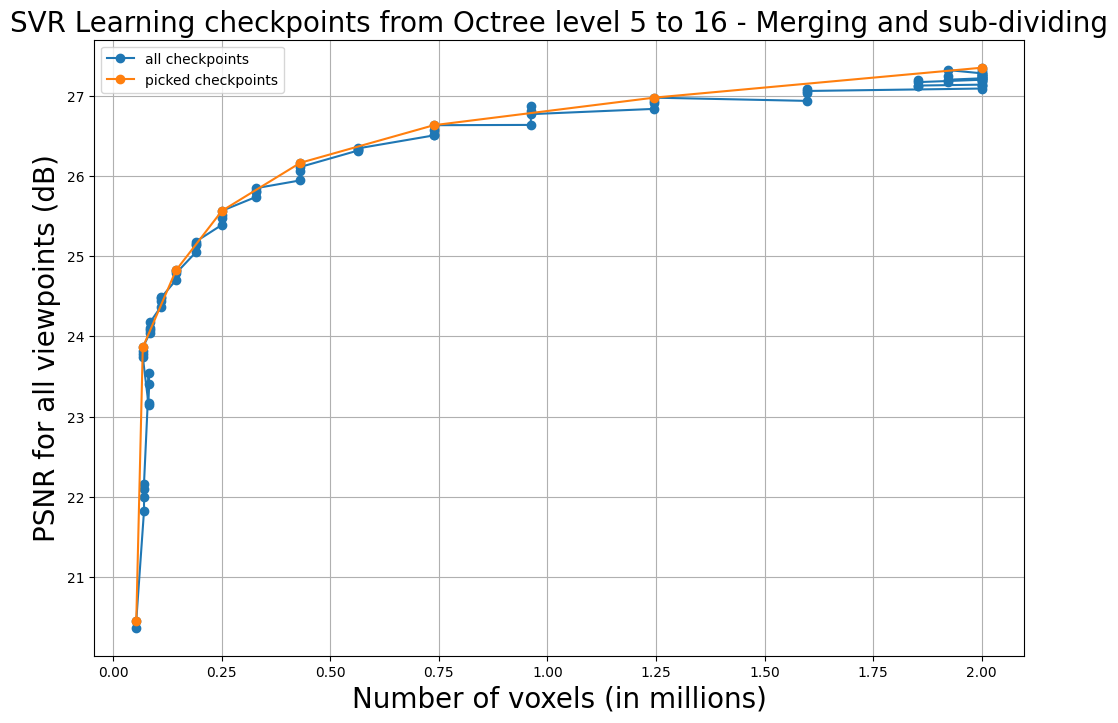

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_num_vox[2:])/1e6, list_psnr[2:], "o-", label="all checkpoints")
ax.plot(np.array(list_num_vox_picked)/1e6, list_psnr_picked, "o-", label="picked checkpoints")
ax.set_ylabel("PSNR for all viewpoints (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20) 
# ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 

plt.title("SVR Learning checkpoints from Octree level 5 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

### 001

In [ ]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

In [3]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [8]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt")
high_res= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

approx_attribute_field = high_res.apply_A_transpose(
    low_res,
    low_res.voxel_attribute_field,
    scene_dataset,
    optim_opt={
        "lr": 0.001,
        "num_scene_loop": 30
    }
)


Apply_A_transpose: loop = 0 iter = 0 psnr=12.586194038391113
Apply_A_transpose: loop = 0 iter = 100 psnr=15.221054077148438
Apply_A_transpose: loop = 0 iter = 200 psnr=16.977718353271484
Apply_A_transpose: loop = 1 iter = 300 psnr=15.741813659667969
Apply_A_transpose: loop = 1 iter = 400 psnr=16.31003761291504
Apply_A_transpose: loop = 1 iter = 500 psnr=21.89857292175293
Apply_A_transpose: loop = 2 iter = 600 psnr=19.50529670715332
Apply_A_transpose: loop = 2 iter = 700 psnr=22.29517364501953
Apply_A_transpose: loop = 2 iter = 800 psnr=23.327533721923828
Apply_A_transpose: loop = 3 iter = 900 psnr=21.83928680419922
Apply_A_transpose: loop = 3 iter = 1000 psnr=23.37173080444336
Apply_A_transpose: loop = 3 iter = 1100 psnr=25.01814079284668
Apply_A_transpose: loop = 4 iter = 1200 psnr=26.318283081054688
Apply_A_transpose: loop = 4 iter = 1300 psnr=22.59892463684082
Apply_A_transpose: loop = 5 iter = 1400 psnr=22.53648567199707
Apply_A_transpose: loop = 5 iter = 1500 psnr=25.9376449584960

In [9]:

list_mse = []
for view in train_views:
    tensor_img = high_res.apply_phi_with_F(approx_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_true     = im_tensor2np(view.rendered_true)

    tensor_img_target = low_res.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 34.798343368492965


In [10]:
list_mse = []
for view in train_views:
    tensor_img = high_res.apply_phi_with_F(approx_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_true     = im_tensor2np(view.rendered_true)

    tensor_img_target = high_res.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 33.627726350203254


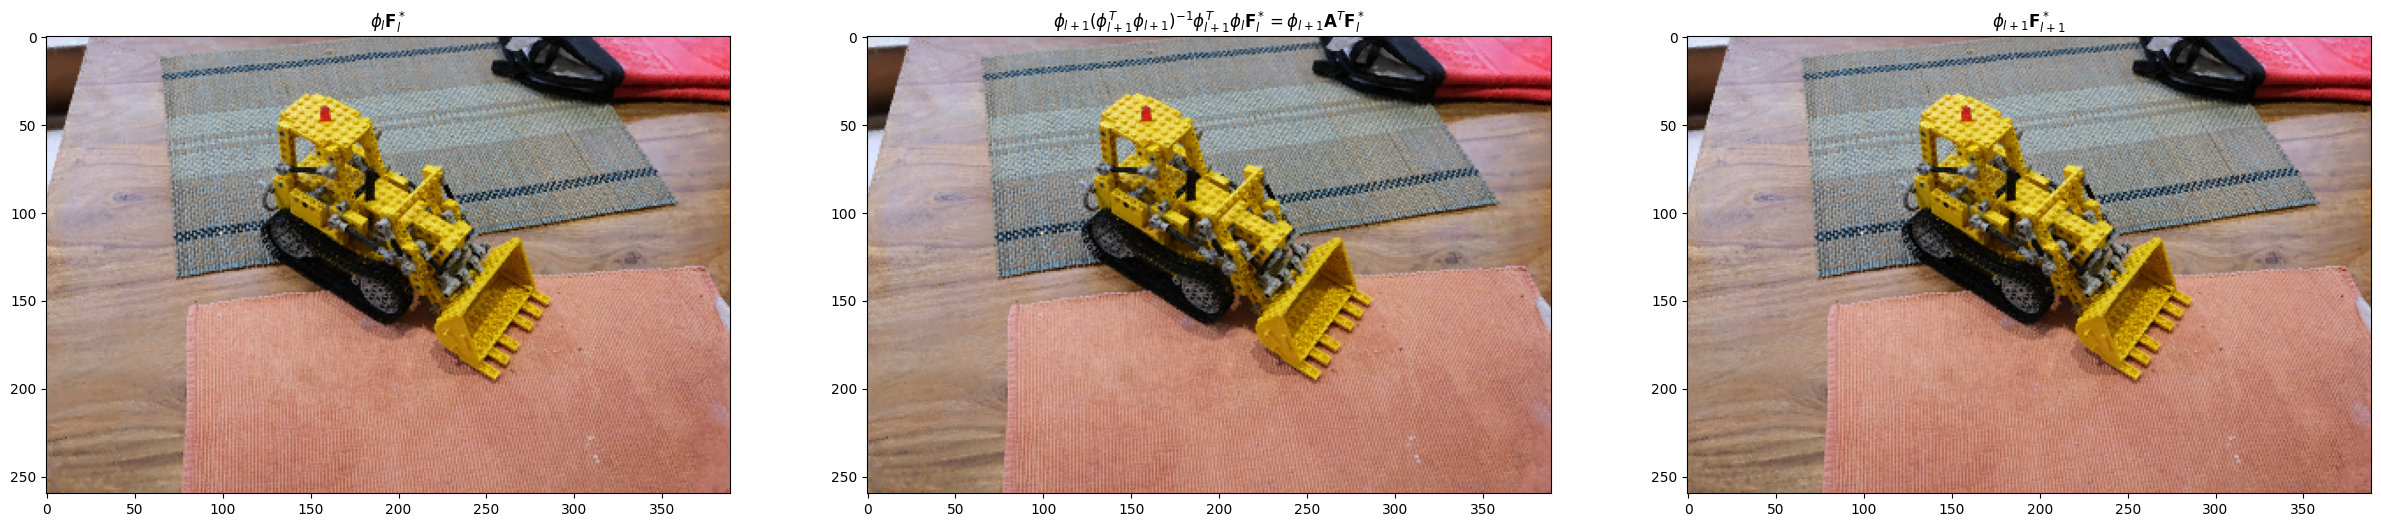

In [11]:
i=50
rendered_img_low = low_res.apply_phi(train_views[i]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[i]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[i]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

### 003

In [4]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

In [ ]:
torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 5,
        "muy_phi": 1.0,
    },
    encoding_opts={
        "lr": 0.005,
        "lambda_l1": 0.0,
        "num_loop": 5,
        "update_frequency": None
    }
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [6]:
all_quantized_coefs, decoded_attribute = encoder.testing_encoding()

Encoding level=1
Apply_A_transpose: loop = 0 iter = 0 psnr=14.048992156982422
Apply_A_transpose: loop = 0 iter = 100 psnr=17.46314239501953
Apply_A_transpose: loop = 0 iter = 200 psnr=19.11639976501465
Apply_A_transpose: loop = 1 iter = 300 psnr=17.29847526550293
Apply_A_transpose: loop = 1 iter = 400 psnr=18.24886131286621
Apply_A_transpose: loop = 1 iter = 500 psnr=24.743202209472656
Apply_A_transpose: loop = 2 iter = 600 psnr=21.45089340209961
Apply_A_transpose: loop = 2 iter = 700 psnr=23.911428451538086
Apply_A_transpose: loop = 2 iter = 800 psnr=23.561870574951172
Apply_A_transpose: loop = 3 iter = 900 psnr=23.243131637573242
Apply_A_transpose: loop = 3 iter = 1000 psnr=22.463558197021484
Apply_A_transpose: loop = 3 iter = 1100 psnr=25.230581283569336
Apply_A_transpose: loop = 4 iter = 1200 psnr=26.3084716796875
Apply_A_transpose: loop = 4 iter = 1300 psnr=20.915014266967773
Apply_A_transpose: loop = 5 iter = 1400 psnr=23.784870147705078
Apply_A_transpose: loop = 5 iter = 1500 ps

In [47]:
for l, coefs in enumerate(all_quantized_coefs):
    min_val = torch.min(coefs, dim=0)[0]
    avg_val = torch.mean(coefs, dim=0)[0]
    max_val = torch.max(coefs, dim=0)[0]

    print(f"level={l} min_val={min_val.cpu().numpy()} avg_val={avg_val.cpu().numpy()} max_val={max_val.cpu().numpy()}")

level=0 min_val=[-3.7670963 -3.8294294 -3.1885269] avg_val=0.0068028816021978855 max_val=[3.4714627 3.0749774 3.7927861]
level=1 min_val=[-2.673486  -2.1632044 -1.8934585] avg_val=-0.00605982169508934 max_val=[1.6994952 1.276602  1.7866479]
level=2 min_val=[-1.9374981 -1.2753897 -1.1414398] avg_val=-0.00506175821647048 max_val=[1.1038102 0.9582167 1.1712182]
level=3 min_val=[-0.8464627 -1.0752939 -0.896135 ] avg_val=0.0012234436580911279 max_val=[0.8375485  0.71623343 1.4425658 ]
level=4 min_val=[-0.8971123 -0.9356184 -1.2398195] avg_val=-0.0007487978436984122 max_val=[0.976269  1.585352  1.5470306]
level=5 min_val=[-0.9797586  -0.7975791  -0.95572186] avg_val=0.0012359835673123598 max_val=[1.3364999  0.85426337 1.7300631 ]
level=6 min_val=[-0.77694863 -1.0153859  -0.8235656 ] avg_val=0.0012989366659894586 max_val=[1.1494939 1.0272834 2.0105069]


In [48]:
for l, coefs in enumerate(all_quantized_coefs):
    min_val = torch.min(torch.abs(coefs), dim=0)[0]
    avg_val = torch.mean(torch.abs(coefs), dim=0)[0]
    max_val = torch.max(torch.abs(coefs), dim=0)[0]

    print(f"level={l} min_abs_val={min_val.cpu().numpy()} avg_abs_val={avg_val.cpu().numpy()} max_abs_val={max_val.cpu().numpy()}")

level=0 min_abs_val=[5.2554345e-08 2.4564778e-07 1.2147892e-07] avg_abs_val=0.20566299557685852 max_abs_val=[3.7670963 3.8294294 3.7927861]
level=1 min_abs_val=[8.672598e-09 5.848564e-08 9.927296e-09] avg_abs_val=0.08569527417421341 max_abs_val=[2.673486  2.1632044 1.8934585]
level=2 min_abs_val=[1.6767819e-08 4.9402608e-08 3.2477733e-08] avg_abs_val=0.047839343547821045 max_abs_val=[1.9374981 1.2753897 1.1712182]
level=3 min_abs_val=[8.7883176e-09 3.3484555e-09 1.6114351e-08] avg_abs_val=0.031839191913604736 max_abs_val=[0.8464627 1.0752939 1.4425658]
level=4 min_abs_val=[2.8815302e-08 2.3205954e-08 4.7642046e-09] avg_abs_val=0.023749811574816704 max_abs_val=[0.976269  1.585352  1.5470306]
level=5 min_abs_val=[2.116403e-10 3.951383e-09 1.911766e-08] avg_abs_val=0.01698077656328678 max_abs_val=[1.3364999  0.85426337 1.7300631 ]
level=6 min_abs_val=[2.0504152e-09 1.8503087e-09 1.1884249e-08] avg_abs_val=0.013276607729494572 max_abs_val=[1.1494939 1.0272834 2.0105069]


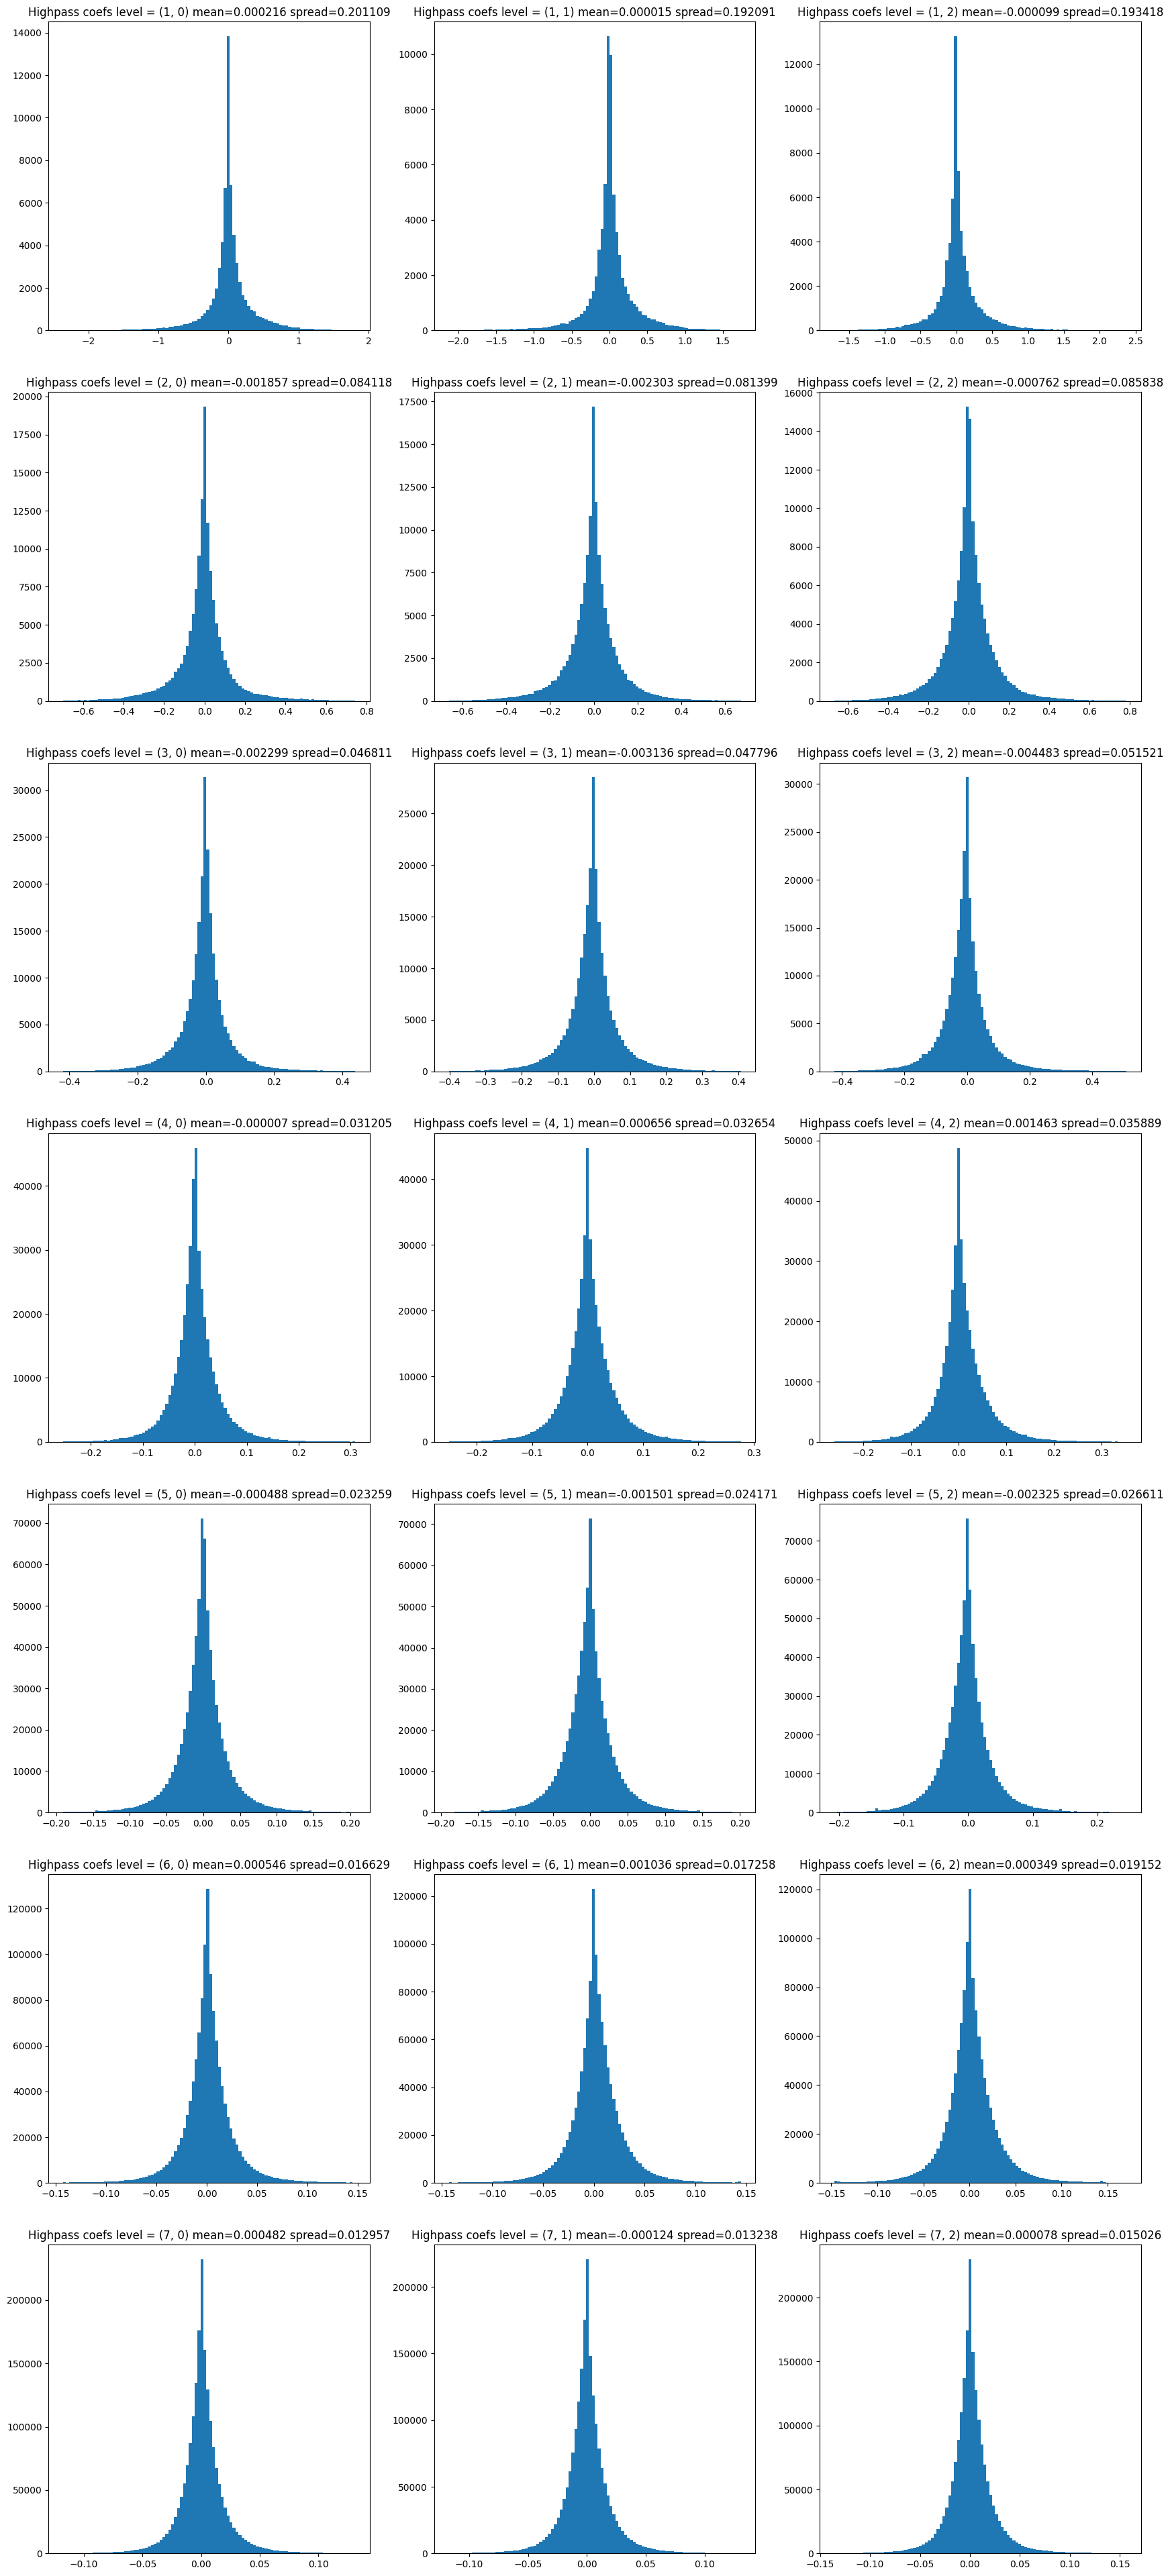

In [53]:

fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(21, 7*7))
for l, coefs in enumerate(all_quantized_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i].cpu().numpy()
        ind = (y > np.percentile(y, 0.1)) & (y < np.percentile(y, 99.9))

        a = np.median(y[ind])
        b = np.mean(np.abs(y[ind] - a))

        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Highpass coefs level = {l+1, i} mean={a:04f} spread={b:04f}")
plt.show()

In [ ]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

In [20]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")


def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 66.90176952444995


In [21]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 27.346742133634066


In [22]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

list_mse = []
for view in test_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 26.75997506157732


# END